# DATA 255 - HW1: Neural Network with One Hidden Layer

**Dataset.** A binary subset of MNIST: `mnist_train_binary.csv` (11,339 samples) and
`mnist_test_binary.csv` (1,850 samples). Each row is 785 values - the label followed by
784 pixels of a 28x28 grayscale image. Label 1 = digit 5, label 0 = digit 6.

**Goal.** Build a 784 -> 100 -> 1 network from scratch and run one forward pass.

**Constraints followed.** PyTorch only (no NumPy, no TensorFlow), no `nn.Linear`,
sigmoid written by hand, random seed 0.

In [1]:
import csv

import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)                                  # random seed = 0
torch.set_printoptions(precision=4, sci_mode=False)   # readable output below

## 1. Load the dataset and display sample images

Each csv starts with a header row (`label, 1x1, 1x2, ...`), so we skip it and read the
remaining rows with Python's built-in `csv` module. The rows go straight into a
`torch.Tensor` - no NumPy is used at any point.

Splitting each row: column 0 is the label, columns 1-784 are the pixels. So the loader
returns `X` of shape `(n, 784)` and `y` of shape `(n,)`.

To display an image we reshape one row of 784 pixels back into the original 28x28 grid.

In [2]:
def load_csv(path):
    with open(path) as f:
        reader = csv.reader(f)
        next(reader)                                    # skip the header row
        rows = [[int(v) for v in row] for row in reader]

    data = torch.tensor(rows, dtype=torch.float32)
    return data[:, 1:], data[:, 0]                      # pixels (n, 784), labels (n,)


X_train, y_train = load_csv("mnist_train_binary.csv")
X_test, y_test = load_csv("mnist_test_binary.csv")

print("train:", tuple(X_train.shape), tuple(y_train.shape))
print("test: ", tuple(X_test.shape), tuple(y_test.shape))
print("pixel range:", X_train.min().item(), "to", X_train.max().item())

train: (11339, 784) (11339,)
test:  (1850, 784) (1850,)
pixel range: 0.0 to 255.0


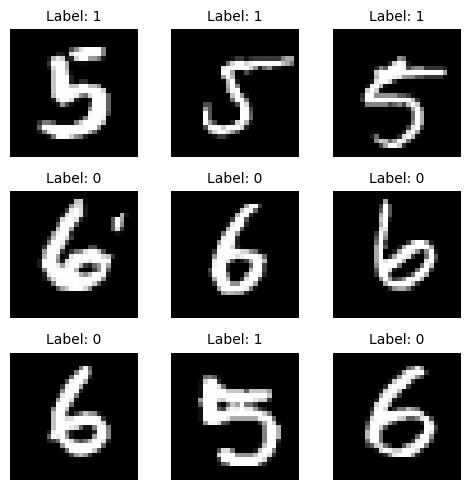

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(5, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")  # 784 pixels -> 28x28 image
    ax.set_title(f"Label: {int(y_train[i])}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

The shapes match the assignment (11,339 train and 1,850 test samples of 784 pixels each)
and the pixel values run from 0 to 255. The nine images are the 5s and 6s of Fig.1, each
labelled 1 for a 5 and 0 for a 6.

## 2. Build the neural network

**Architecture (Fig.2).** Three layers, fully connected:

| Layer | Neurons | Weight matrix | Activation |
|---|---|---|---|
| Input | 784 | - | - |
| Hidden | 100 | $W^{[1]}$: 784 x 100 | sigmoid |
| Output | 1 | $W^{[2]}$: 100 x 1 | sigmoid |

**No bias.** The note says the bias term may be omitted, so each layer is a plain matrix
multiplication.

**Sigmoid, written from scratch:**

$$\sigma(z) = \frac{1}{1 + \exp(-z)}$$

**Forward pass.** For a batch $X$ of shape $(m, 784)$:

$$Z^{[1]} = X W^{[1]} \;\;(m \times 100), \qquad a^{[1]} = \sigma(Z^{[1]})$$
$$Z^{[2]} = a^{[1]} W^{[2]} \;\;(m \times 1), \qquad a^{[2]} = \sigma(Z^{[2]})$$

**Initialization.** The weights must be non-zero, so they are drawn from a standard
normal with `torch.randn` and scaled by 0.01. The small scale keeps $Z$ near 0, where the
sigmoid has its steepest slope - large weights would saturate it at 0 or 1 instead.

In [4]:
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))


class NeuralNetwork:
    def __init__(self, n_input=784, n_hidden=100, n_output=1):
        # small non-zero random weights; no bias terms
        self.W1 = torch.randn(n_input, n_hidden) * 0.01
        self.W2 = torch.randn(n_hidden, n_output) * 0.01

    def forward(self, X):
        a1 = sigmoid(X @ self.W1)     # hidden layer
        a2 = sigmoid(a1 @ self.W2)    # output layer
        return a2

## 3. Calculate $a^{[2]}$ for the first 64 training samples

Two steps before the forward pass:

1. **Normalize** the pixels from [0, 255] to [0, 1] by dividing by 255. Without this the
   inputs to the hidden layer would be ~255x larger and would saturate the sigmoid.
2. **Reset the seed to 0** right before creating the model, so the weights - and therefore
   the numbers below - are reproducible.

The first 64 rows of the training set are then passed through the network, giving one
output per sample: $a^{[2]}$ of shape $(64, 1)$.

In [5]:
X_train = X_train / 255.0    # normalize [0, 255] -> [0, 1]
X_test = X_test / 255.0

torch.manual_seed(0)
model = NeuralNetwork()

a2 = model.forward(X_train[:64])

print("a2 shape:", tuple(a2.shape))
print(a2)

a2 shape: (64, 1)
tensor([[0.4949],
        [0.4936],
        [0.4950],
        [0.4947],
        [0.4947],
        [0.4948],
        [0.4947],
        [0.4950],
        [0.4943],
        [0.4938],
        [0.4944],
        [0.4948],
        [0.4942],
        [0.4947],
        [0.4951],
        [0.4943],
        [0.4944],
        [0.4943],
        [0.4947],
        [0.4945],
        [0.4942],
        [0.4944],
        [0.4942],
        [0.4939],
        [0.4939],
        [0.4948],
        [0.4946],
        [0.4942],
        [0.4947],
        [0.4940],
        [0.4950],
        [0.4943],
        [0.4944],
        [0.4946],
        [0.4944],
        [0.4939],
        [0.4945],
        [0.4942],
        [0.4951],
        [0.4942],
        [0.4945],
        [0.4940],
        [0.4942],
        [0.4946],
        [0.4946],
        [0.4943],
        [0.4942],
        [0.4948],
        [0.4947],
        [0.4947],
        [0.4944],
        [0.4942],
        [0.4944],
        [0.4944],
        [0

Every output is close to 0.5 (about 0.4936 to 0.4951). This is the expected result: the
network is **untrained**, and with weights near zero $Z^{[2]} = a^{[1]} W^{[2]} \approx 0$,
so $a^{[2]} = \sigma(0) = 0.5$. The small differences between samples come from the
different input images. Training would push these values toward 0 and 1.